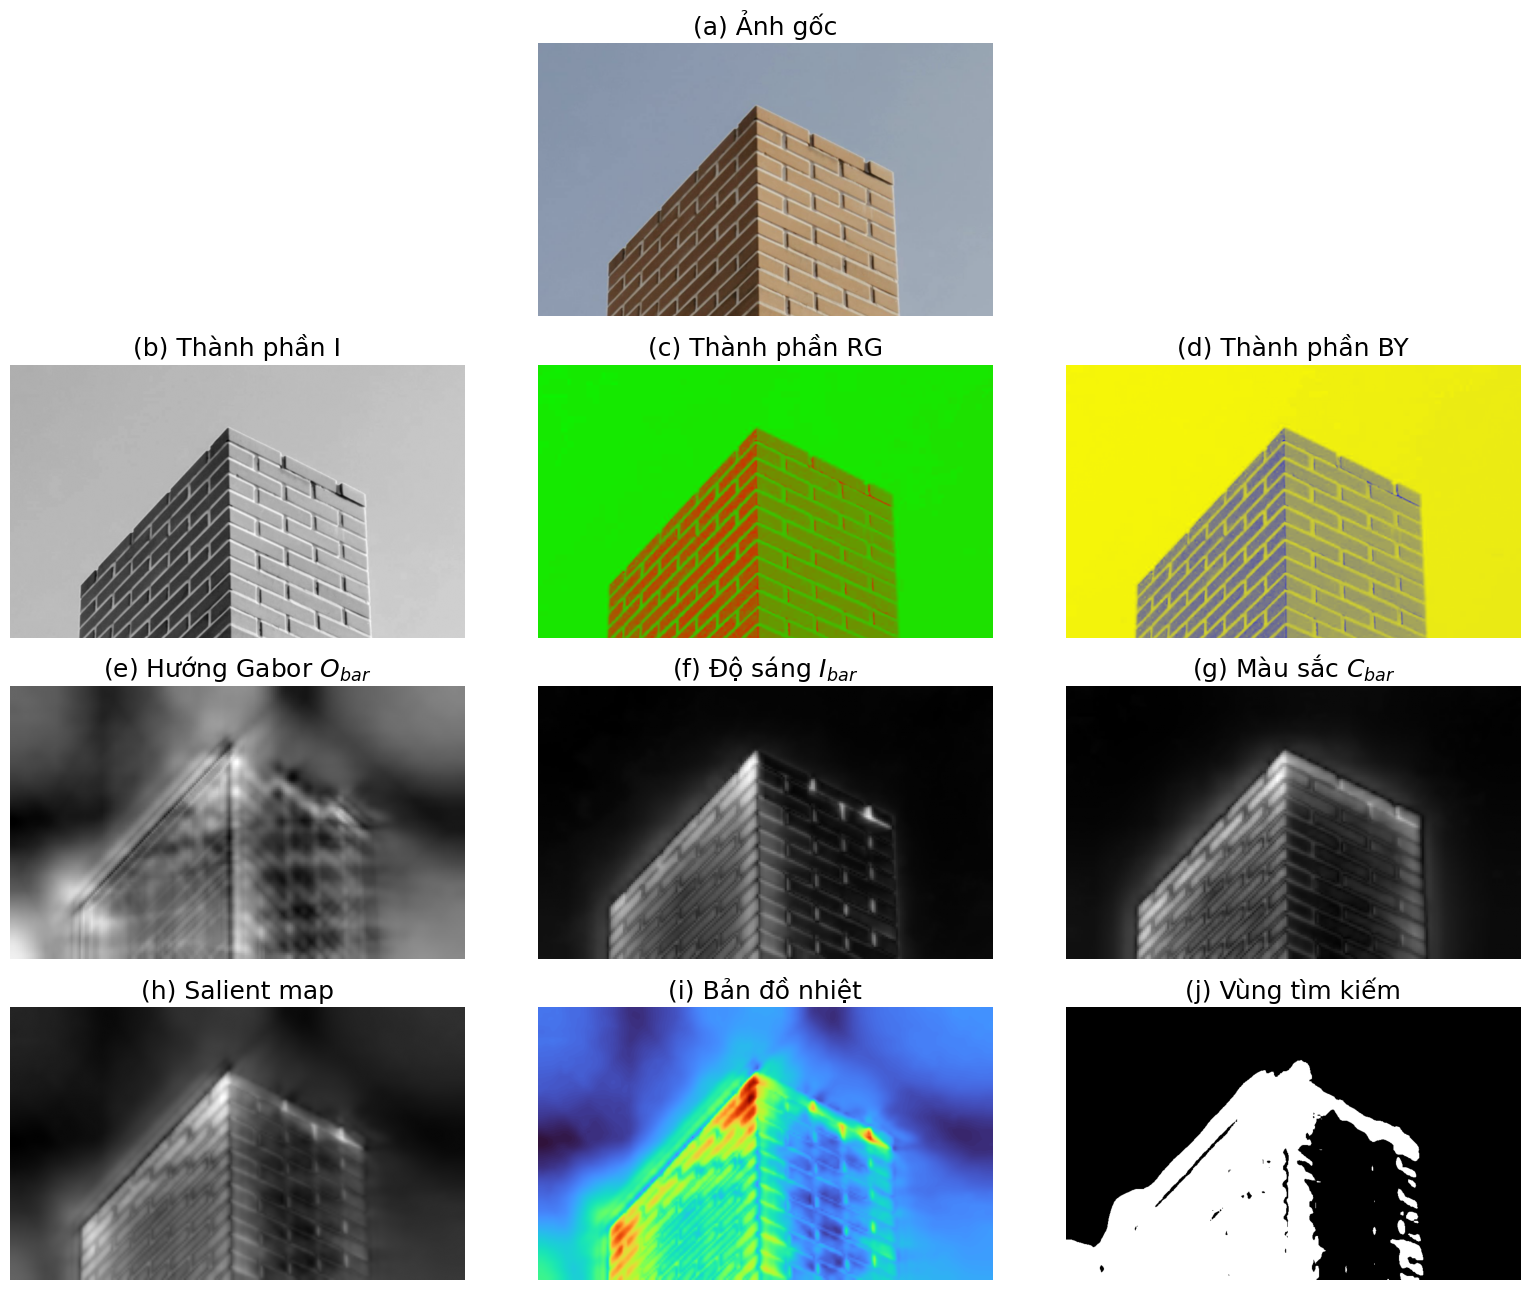

Kích thước ảnh gốc: (540, 899, 3)
Kích thước salient map: (540, 899)
Giá trị nhỏ nhất của S_full: 0.00012754003
Giá trị lớn nhất của S_full: 0.9984864
Số pixel thuộc vùng tìm kiếm: 140393
Kiểm tra hoàn tất: chương trình chạy đúng.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: BẢN ĐỒ NỔI BẬT THỊ GIÁC DỰA TRÊN I, C, O
# Chương/Mục liên quan: Chương 6 - Phát hiện vùng nổi bật và chú ý thị giác
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách xây dựng bản đồ nổi bật thị giác từ độ sáng, màu sắc và hướng.
# - Giúp người học quan sát vai trò của các thành phần I, RG, BY và Gabor.
# - Liên hệ code với mô hình center-surround trong phát hiện vùng nổi bật.

# Sau khi chạy code, người học cần:
# 1. Hiểu cách tách ảnh thành các thành phần độ sáng, màu sắc và hướng.
# 2. Quan sát được cách các bản đồ đặc trưng được cộng hợp thành salient map.
# 3. Biết kiểm tra vùng ảnh có khả năng thu hút chú ý thị giác.

# Input:
# - Dữ liệu đầu vào: ảnh màu từ GitHub
# - Kiểu dữ liệu: ảnh RGB

# Output:
# - Ảnh gốc
# - Thành phần I, RG, BY
# - Bản đồ hướng O_bar
# - Bản đồ độ sáng I_bar
# - Bản đồ màu sắc C_bar
# - Salient map
# - Vùng tìm kiếm sau ngưỡng Otsu

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    I_bgr = cv2.imdecode(img, cv2.IMREAD_COLOR)

    if I_bgr is None:
        raise ValueError("Không đọc được ảnh từ URL.")

    return I_bgr

image_url = "https://github.com/lthavnu/cv-book/raw/main/images/chimney.png"

I_bgr = read_gitlab_image(image_url)
I_rgb = cv2.cvtColor(I_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

# ============================================================
# 3. CÁC HÀM PHỤ TRỢ
# ============================================================

def normalize_to_01(X):
    X = X.astype(np.float32)
    x_min = np.min(X)
    x_max = np.max(X)

    if x_max - x_min < 1e-8:
        return np.zeros_like(X, dtype=np.float32)

    return (X - x_min) / (x_max - x_min)


def resize_to_shape(X, target_shape):
    H, W = target_shape[:2]
    return cv2.resize(X, (W, H), interpolation=cv2.INTER_LINEAR)


def normalize_feature_map(X):
    return normalize_to_01(X)

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

def compute_r_g_b(I_rgb):
    R = I_rgb[:, :, 0].astype(np.float32)
    G = I_rgb[:, :, 1].astype(np.float32)
    B = I_rgb[:, :, 2].astype(np.float32)

    denominator = R + G + B + 1e-8

    # Công thức trong giáo trình:
    # r = R / (R + G + B)
    # g = G / (R + G + B)
    # b = B / (R + G + B)
    r = R / denominator
    g = G / denominator
    b = B / denominator

    return R, G, B, r, g, b


def compute_I(R, G, B):
    # Công thức trong giáo trình:
    # I = (R + G + B) / 3
    return ((R + G + B) / 3.0).astype(np.float32)


def compute_RG_BY(r, g, b):
    # Công thức trong giáo trình:
    # RG = 3/2(r - g)
    # BY = 2b - max(r, g)
    RG = 1.5 * (r - g)
    BY = 2.0 * b - np.maximum(r, g)

    return RG.astype(np.float32), BY.astype(np.float32)


def build_gaussian_pyramid(X, num_levels=9):
    X = X.astype(np.float32)
    pyramid = [X]

    for _ in range(1, num_levels):
        X = cv2.pyrDown(X)
        pyramid.append(X)

    return pyramid


def create_gabor_kernel(theta_deg, ksize=31, sigma=4.0, lambd=10.0, gamma=0.5, psi=0.0):
    theta_rad = np.deg2rad(theta_deg)

    kernel = cv2.getGaborKernel(
        (ksize, ksize),
        sigma=sigma,
        theta=theta_rad,
        lambd=lambd,
        gamma=gamma,
        psi=psi,
        ktype=cv2.CV_32F
    )

    return kernel


def compute_gabor_response_pyramid(I_pyramid, theta_list_deg):
    O_theta_pyramids = {}

    for theta_deg in theta_list_deg:
        kernel = create_gabor_kernel(theta_deg)
        O_theta_pyramid = []

        for I_s in I_pyramid:
            O_theta_s = cv2.filter2D(I_s, cv2.CV_32F, kernel)
            O_theta_pyramid.append(np.abs(O_theta_s))

        O_theta_pyramids[theta_deg] = O_theta_pyramid

    return O_theta_pyramids


def compute_center_surround_from_pyramid(pyramid, center_surround_pairs):
    CS_maps = []

    for (c, s) in center_surround_pairs:
        X_c = pyramid[c]
        X_s = pyramid[s]
        X_s_up = resize_to_shape(X_s, X_c.shape)

        # Công thức trong giáo trình:
        # CS(c, s) = |X(c) - upsample(X(s))|
        CS = np.abs(X_c - X_s_up)

        CS_maps.append({
            "c": c,
            "s": s,
            "CS": CS
        })

    return CS_maps


def compute_O_bar(O_theta_pyramids, center_surround_pairs, theta_list_deg, target_shape):
    O_bar = np.zeros(target_shape, dtype=np.float32)

    for theta_deg in theta_list_deg:
        O_theta_pyramid = O_theta_pyramids[theta_deg]

        O_theta_CS_maps = compute_center_surround_from_pyramid(
            O_theta_pyramid,
            center_surround_pairs
        )

        O_theta_sum = np.zeros(target_shape, dtype=np.float32)

        for item in O_theta_CS_maps:
            O_theta_CS = normalize_feature_map(item["CS"])
            O_theta_CS = resize_to_shape(O_theta_CS, target_shape)
            O_theta_sum += O_theta_CS

        O_theta_sum = normalize_feature_map(O_theta_sum)
        O_bar += O_theta_sum

    O_bar = normalize_feature_map(O_bar)

    return O_bar


def compute_I_bar(I_pyramid, center_surround_pairs, target_shape):
    I_CS_maps = compute_center_surround_from_pyramid(I_pyramid, center_surround_pairs)
    I_bar = np.zeros(target_shape, dtype=np.float32)

    for item in I_CS_maps:
        I_CS = normalize_feature_map(item["CS"])
        I_CS = resize_to_shape(I_CS, target_shape)
        I_bar += I_CS

    I_bar = normalize_feature_map(I_bar)

    return I_bar


def compute_C_bar(RG_pyramid, BY_pyramid, center_surround_pairs, target_shape):
    RG_CS_maps = compute_center_surround_from_pyramid(RG_pyramid, center_surround_pairs)
    BY_CS_maps = compute_center_surround_from_pyramid(BY_pyramid, center_surround_pairs)

    C_bar = np.zeros(target_shape, dtype=np.float32)

    for RG_item, BY_item in zip(RG_CS_maps, BY_CS_maps):
        RG_CS = normalize_feature_map(RG_item["CS"])
        BY_CS = normalize_feature_map(BY_item["CS"])

        C_CS = RG_CS + BY_CS
        C_CS = resize_to_shape(C_CS, target_shape)

        C_bar += C_CS

    C_bar = normalize_feature_map(C_bar)

    return C_bar


def compute_salient_map(O_bar, I_bar, C_bar):
    # Công thức trong giáo trình:
    # S = O_bar + I_bar + C_bar
    S = O_bar + I_bar + C_bar
    return normalize_feature_map(S)


def visualize_RG(RG):
    RG_n = normalize_to_01(RG)
    H, W = RG.shape

    RG_rgb = np.zeros((H, W, 3), dtype=np.float32)
    RG_rgb[:, :, 0] = RG_n
    RG_rgb[:, :, 1] = 1.0 - RG_n
    RG_rgb[:, :, 2] = 0.0

    return np.clip(RG_rgb, 0, 1)


def visualize_BY(BY):
    BY_n = normalize_to_01(BY)
    H, W = BY.shape

    BY_rgb = np.zeros((H, W, 3), dtype=np.float32)

    RG_y = BY_n
    B_ch = 1.0 - BY_n

    BY_rgb[:, :, 0] = RG_y
    BY_rgb[:, :, 1] = RG_y
    BY_rgb[:, :, 2] = B_ch

    return np.clip(BY_rgb, 0, 1)


def compute_search_region(S_full):
    S_u8 = (255 * normalize_to_01(S_full)).astype(np.uint8)

    # Thuật toán dùng trong giáo trình:
    # Ngưỡng Otsu để tách vùng nổi bật khỏi nền
    _, binary = cv2.threshold(
        S_u8,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return binary


R, G, B, r, g, b = compute_r_g_b(I_rgb)

I = compute_I(R, G, B)

RG, BY = compute_RG_BY(r, g, b)

num_levels = 9

I_pyramid = build_gaussian_pyramid(I, num_levels=num_levels)
RG_pyramid = build_gaussian_pyramid(RG, num_levels=num_levels)
BY_pyramid = build_gaussian_pyramid(BY, num_levels=num_levels)

theta_list_deg = [0, 45, 90, 135]

O_theta_pyramids = compute_gabor_response_pyramid(
    I_pyramid,
    theta_list_deg
)

center_surround_pairs = [
    (2, 5),
    (2, 6),
    (3, 6),
    (3, 7),
    (4, 7),
    (4, 8)
]

target_shape = I_pyramid[2].shape

O_bar = compute_O_bar(
    O_theta_pyramids,
    center_surround_pairs,
    theta_list_deg,
    target_shape
)

I_bar = compute_I_bar(
    I_pyramid,
    center_surround_pairs,
    target_shape
)

C_bar = compute_C_bar(
    RG_pyramid,
    BY_pyramid,
    center_surround_pairs,
    target_shape
)

S = compute_salient_map(O_bar, I_bar, C_bar)

S_full = resize_to_shape(S, I.shape)

search_region = compute_search_region(S_full)

I_vis = normalize_to_01(I)
RG_vis = visualize_RG(RG)
BY_vis = visualize_BY(BY)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(16, 13))

ax = plt.subplot(4, 3, 2)
ax.imshow(I_rgb)
ax.set_title("(a) Ảnh gốc", fontsize=18)
ax.axis("off")

ax = plt.subplot(4, 3, 4)
ax.imshow(I_vis, cmap="gray")
ax.set_title("(b) Thành phần I", fontsize=18)
ax.axis("off")

ax = plt.subplot(4, 3, 5)
ax.imshow(RG_vis)
ax.set_title("(c) Thành phần RG", fontsize=18)
ax.axis("off")

ax = plt.subplot(4, 3, 6)
ax.imshow(BY_vis)
ax.set_title("(d) Thành phần BY", fontsize=18)
ax.axis("off")

ax = plt.subplot(4, 3, 7)
ax.imshow(O_bar, cmap="gray")
ax.set_title(r"(e) Hướng Gabor $O_{bar}$", fontsize=18)
ax.axis("off")

ax = plt.subplot(4, 3, 8)
ax.imshow(I_bar, cmap="gray")
ax.set_title(r"(f) Độ sáng $I_{bar}$", fontsize=18)
ax.axis("off")

ax = plt.subplot(4, 3, 9)
ax.imshow(C_bar, cmap="gray")
ax.set_title(r"(g) Màu sắc $C_{bar}$", fontsize=18)
ax.axis("off")

ax = plt.subplot(4, 3, 10)
ax.imshow(S_full, cmap="gray")
ax.set_title("(h) Salient map", fontsize=18)
ax.axis("off")

ax = plt.subplot(4, 3, 11)
ax.imshow(S_full, cmap="turbo")
ax.set_title("(i) Bản đồ nhiệt", fontsize=18)
ax.axis("off")

ax = plt.subplot(4, 3, 12)
ax.imshow(search_region, cmap="gray")
ax.set_title("(j) Vùng tìm kiếm", fontsize=18)
ax.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kích thước ảnh gốc:", I_rgb.shape)
print("Kích thước salient map:", S_full.shape)
print("Giá trị nhỏ nhất của S_full:", np.min(S_full))
print("Giá trị lớn nhất của S_full:", np.max(S_full))
print("Số pixel thuộc vùng tìm kiếm:", np.sum(search_region > 0))

assert I_rgb.ndim == 3 and I_rgb.shape[2] == 3
assert S_full.shape == I.shape
assert np.min(S_full) >= 0.0 and np.max(S_full) <= 1.0
assert search_region.shape == I.shape

print("Kiểm tra hoàn tất: chương trình chạy đúng.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi theta_list_deg để quan sát ảnh hưởng của số hướng Gabor.
# 2. Thay đổi center_surround_pairs để quan sát ảnh hưởng của cặp mức center-surround.
# 3. Thay đổi tham số ksize, sigma, lambd trong create_gabor_kernel để quan sát ảnh hưởng của bộ lọc Gabor.